# 03 — Análise Comparativa entre modelos (T1 — TON_IoT)

Consolida as entregas do grupo, audita o que está preenchido, e produz
as visualizações comparativas que vão pra apresentação.

**Status (2026-05-22)**: **5/5 modelos entregues** —
ClusWiSARD (pure-Python), BloomWiSARD (pure-Python), BTHOWeN (Colab
+ VsCode), WiSARD (C++ fork), ULEEN. Cada modelo também tem um
gabarito local (`_reference/<modelo>/`) rodado pelo coringa
pra validação cruzada.

**Decisões aplicadas** (ver `handoff_entregas_2026-05-21.md`):

- **Tarefa principal = binário**. Multi-classe vai pra anexo (§6) com
  F1 macro **e** AUC OvR lado a lado (AUC sobrevive ao colapso de F1).
- **Memória oficial = `serialized`** (o `theoretical` do BTHOWeN VsCode
  está bugado; sidequest).
- **Garage_Door / Motion_Light** ficam — analisadas como casos
  patológicos em §7 com explicação informacional.
- **BTHOWeN** tem 2 runs (`colab` e `vscode`); para tudo exceto
  comparação de tempo cross-machine, contam como **um único modelo**
  (mesma pessoa, mesma implementação, ambientes diferentes).

Esse notebook é incremental: pra trocar uma entrega, dropar em
`results/<modelo>/` (json ou jsonl) e re-executar.

## 0. Setup

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd()))
import sweep_utils as sw

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 220)
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

# Paleta por MODELO (não por submissão). Submissões do mesmo modelo
# compartilham cor — colapsam na Pareto principal.
COLOR_BY_MODEL = {
    "BTHOWeN":    "#1f77b4",
    "ClusWiSARD": "#d62728",
    "WiSARD":     "#2ca02c",
    "BloomWiSARD":"#9467bd",
    "ULEEN":      "#ff7f0e",
}

## 1. Inventário

In [2]:
RESULTS = Path("results")
for sub in sorted(RESULTS.rglob("*__*.json")):
    print(" ", sub.relative_to(RESULTS))

  _reference/bloomwisard/Fridge__binary.json
  _reference/bloomwisard/Fridge__multiclass.json
  _reference/bloomwisard/GPS_Tracker__binary.json
  _reference/bloomwisard/GPS_Tracker__multiclass.json
  _reference/bloomwisard/Garage_Door__binary.json
  _reference/bloomwisard/Garage_Door__multiclass.json
  _reference/bloomwisard/Modbus__binary.json
  _reference/bloomwisard/Modbus__multiclass.json
  _reference/bloomwisard/Motion_Light__binary.json
  _reference/bloomwisard/Motion_Light__multiclass.json
  _reference/bloomwisard/Thermostat__binary.json
  _reference/bloomwisard/Thermostat__multiclass.json
  _reference/bloomwisard/Weather__binary.json
  _reference/bloomwisard/Weather__multiclass.json
  _reference/bthowen/Fridge__binary.json
  _reference/bthowen/Fridge__multiclass.json
  _reference/bthowen/GPS_Tracker__binary.json
  _reference/bthowen/GPS_Tracker__multiclass.json
  _reference/bthowen/Garage_Door__binary.json
  _reference/bthowen/Garage_Door__multiclass.json
  _reference/bthowen/M

In [3]:
df = sw.load_all_results(RESULTS)
print(f"Total de linhas (config × base × task × submissão): {len(df):,}")
df.head(3)

Total de linhas (config × base × task × submissão): 32,316


,model,submission,base,task,encoder_type,encoder_size,address_size,bits_total,n_features_num,n_features_cat,cat_bits,skipped,skipped_reason,accuracy,precision_macro,precision_weighted,recall_macro,recall_weighted,f1_macro,f1_weighted,auc_roc,memory_bytes_serialized,memory_bytes_theoretical,train_time_s,inference_latency_us,model_hyperparams,confusion_matrix,labels,machine,timestamp,source_file
0,ClusWiSARD,cluswisard_purepython,Fridge,binary,Distributive,8,4,9,NaN,NaN,NaN,False,NaN,0.624499,0.31225,0.389999,0.5,0.624499,0.384426,0.480147,NaN,2972.0,NaN,0.03384,9.4324,"{'min_score': 0.0, 'threshold': 1, 'discrimina...","[[0, 4500], [0, 7484]]","[0, 1]",NaN,NaN,results/cluswisard/Fridge__binary.json
1,ClusWiSARD,cluswisard_purepython,Fridge,binary,Distributive,8,8,9,NaN,NaN,NaN,False,NaN,0.624499,0.31225,0.389999,0.5,0.624499,0.384426,0.480147,NaN,2752.0,NaN,0.07924,19.8495,"{'min_score': 0.0, 'threshold': 1, 'discrimina...","[[0, 4500], [0, 7484]]","[0, 1]",NaN,NaN,results/cluswisard/Fridge__binary.json
2,ClusWiSARD,cluswisard_purepython,Fridge,binary,Distributive,16,4,17,NaN,NaN,NaN,False,NaN,0.624499,0.31225,0.389999,0.5,0.624499,0.384426,0.480147,NaN,7318.0,NaN,0.25597,101.6584,"{'min_score': 0.0, 'threshold': 1, 'discrimina...","[[0, 4500], [0, 7484]]","[0, 1]",NaN,NaN,results/cluswisard/Fridge__binary.json


## 2. Auditoria

### 2.1 Cobertura por (modelo, base, task)

`PLANO.md` §3.1 pede **192 configs × 14 (base × task) = 2 688** por modelo.
BTHOWeN tem isenção (§3.2): pode fixar Gaussian. Bases pobres
(Garage_Door, Motion_Light) skipam quase tudo por `addressSize > input_bits`.

In [4]:
cov = sw.coverage_summary(df)
cov_pivot = (cov
    .assign(coverage=lambda d: d["n_valid"].astype(str) + "/" + d["n_total"].astype(str))
    .pivot_table(index=["base","task"],
                 columns=["model","submission"],
                 values="coverage",
                 aggfunc="first"))
cov_pivot

model                         BTHOWeN                                             BloomWiSARD                                  ClusWiSARD                       ULEEN                   WiSARD                 
submission              bthowen_colab bthowen_reference bthowen_vscode bloomwisard_purepython bloomwisard_reference cluswisard_purepython cluswisard_reference  uleen uleen_reference   wisard wisard_reference
base         task                                                                                                                                                                                              
Fridge       binary             23/48           138/288        156/216                360/360               368/768                 16/16                12/24  64/72           12/16  184/384           92/192
             multiclass         23/48             0/288        156/216                360/360               368/768                 16/16                12/24  64/72            0/16  184/384           92/192
GPS_Tracker  binary             31/48           186/288        192/216                432/432               496/768                 18/18                20/24  64/72           16/16  248/384          124/192
             multiclass         31/48             0/288        192/216                432/432               496/768                 18/18                20/24  64/72            0/16  248/384          124/192
Garage_Door  binary             23/48           138/288          0/216                    NaN               368/768                   NaN                12/24  64/72           12/16  184/384           92/192
             multiclass         23/48             0/288          0/216                    NaN               368/768                   NaN                12/24  64/72            0/16  184/384           92/192
Modbus       binary             38/48           228/288        216/216                432/432               608/768                 18/18                24/24  72/72           16/16  304/384          152/192
             multiclass         38/48             0/288        216/216                432/432               608/768                 18/18                24/24  72/72            0/16  304/384          152/192
Motion_Light binary             23/48           138/288          0/216                    NaN               368/768                   NaN                12/24  64/72           12/16  184/384           92/192
             multiclass         23/48             0/288          0/216                    NaN               368/768                   NaN                12/24  64/72            0/16  184/384           92/192
Thermostat   binary             31/48           186/288        156/216                360/360               496/768                 16/16                20/24  64/72           16/16  248/384          124/192
             multiclass         31/48             0/288        156/216                360/360               496/768                 16/16                20/24  64/72            0/16  248/384          124/192
Weather      binary             34/48           204/288        204/216                432/432               544/768                 18/18                24/24  64/72           16/16  272/384          136/192
             multiclass         34/48             0/288        204/216                432/432               544/768                 18/18                24/24  64/72            0/16  272/384          136/192

### 2.2 Eixos efetivamente variados por submissão

Inclui os eixos comuns (termômetro/size/address) **e** os
model-specific (`filter_entries`/`filter_hashes` no BTHOWeN, etc).
Sem isso parece que "BTHOWeN VsCode tem menos eixos mas mais
configs" — quando na verdade o VsCode varre 2 eixos extras.

In [5]:
sw.axes_summary(df)

,model,submission,n_configs,thermo_types,thermo_sizes,addr_sizes,bleach_value,numBits,numHashes,filter_entries,filter_hashes,filter_size,hash_mode,num_hashes,min_score,epochs,n_submodels,negativeEvidence
0,BTHOWeN,bthowen_colab,672,[Gaussian],"[2, 4, 8, 16, 32, 64]","[4, 8, 12, 16, 20, 24, 28, 32]","[3, 4, 5, 6, 7, 8, 9, 11, 12, 13, 14, 15, 17, ...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,BTHOWeN,bthowen_reference,4032,[Gaussian],"[2, 4, 8, 16, 32, 64]","[4, 8, 12, 16, 20, 24, 28, 32]",NaN,"[16, 64, 256]","[2, 4]",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,BTHOWeN,bthowen_vscode,3024,[Gaussian],"[2, 4, 8, 16, 32, 64]","[4, 6, 8]","[1, 34, 41, 108, 112, 114, 115, 118, 127, 129,...",NaN,NaN,"[16, 64, 256, 1024]","[3, 5, 7]",NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,BloomWiSARD,bloomwisard_purepython,4032,"[Distributive, Gaussian]","[8, 16]","[4, 8, 16]",NaN,NaN,NaN,NaN,NaN,"[16, 64, 256, 1024]","[h3, murmur, simhash]","[2, 4, 8]",NaN,NaN,NaN,NaN
4,BloomWiSARD,bloomwisard_reference,10752,"[Distributive, Exponential, Gaussian, Simple]","[2, 4, 8, 16, 32, 64]","[4, 8, 12, 16, 20, 24, 28, 32]",NaN,"[256, 1024]","[2, 4]",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,ClusWiSARD,cluswisard_purepython,172,"[Distributive, Gaussian]","[8, 16, 32]","[4, 8, 16]",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,ClusWiSARD,cluswisard_reference,336,"[Distributive, Gaussian]","[8, 16]","[8, 16, 24]",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"[0.1, 0.3]",NaN,NaN,NaN
7,ULEEN,uleen,1008,"[gaussian, linear]","[4, 8, 16]","[4, 8, 16]",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"[10, 30]","[1, 3]",NaN
8,ULEEN,uleen_reference,224,[Gaussian],"[4, 8]","[4, 8]",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"[10, 30]","[1, 3]",NaN
9,WiSARD,wisard,5376,"[Distributive, Exponential, Gaussian, Simple]","[2, 4, 8, 16, 32, 64]","[4, 8, 12, 16, 20, 24, 28, 32]",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"[False, True]"


### 2.3 Fidelidade ao schema do PLANO

Fração de configs **válidas** (não skipped) com cada campo preenchido.
ClusWiSARD não preenche `machine`/`timestamp`/`memory_theoretical` —
fixo na entrega, não bloqueia a análise.

In [6]:
KEY_COLS = ["machine","timestamp","memory_bytes_theoretical",
            "memory_bytes_serialized","train_time_s","inference_latency_us",
            "auc_roc","f1_macro","cat_bits","bits_total"]
(df[~df["skipped"]]
   .groupby(["model","submission"])[KEY_COLS]
   .apply(lambda d: d.notna().mean().round(2)))

machine  timestamp  memory_bytes_theoretical  memory_bytes_serialized  train_time_s  inference_latency_us  auc_roc  f1_macro  cat_bits  bits_total
model       submission                                                                                                                                                                
BTHOWeN     bthowen_colab               1.0        1.0                       1.0                      1.0           1.0                   1.0     1.00       1.0       1.0         1.0
            bthowen_reference           1.0        1.0                       1.0                      1.0           1.0                   1.0     0.00       1.0       1.0         1.0
            bthowen_vscode              1.0        1.0                       1.0                      1.0           1.0                   1.0     1.00       1.0       1.0         1.0
BloomWiSARD bloomwisard_purepython      0.0        0.0                       0.0                      1.0           1.0                   1.0     1.00       1.0       0.0         1.0
            bloomwisard_reference       1.0        1.0                       1.0                      1.0           1.0                   1.0     1.00       1.0       1.0         1.0
ClusWiSARD  cluswisard_purepython       0.0        0.0                       0.0                      1.0           1.0                   1.0     0.00       1.0       0.0         1.0
            cluswisard_reference        1.0        1.0                       1.0                      1.0           1.0                   1.0     0.50       1.0       1.0         1.0
ULEEN       uleen                       1.0        1.0                       1.0                      1.0           1.0                   1.0     0.50       1.0       1.0         1.0
            uleen_reference             1.0        1.0                       1.0                      1.0           1.0                   1.0     0.00       1.0       1.0         1.0
WiSARD      wisard                      1.0        1.0                       1.0                      1.0           1.0                   1.0     0.99       1.0       1.0         1.0
            wisard_reference            1.0        1.0                       1.0                      1.0           1.0                   1.0     0.99       1.0       1.0         1.0

## 3. Headline: ranking binário

In [7]:
# best_per_base agora agrupa só por model (BTHOWeN colab+vscode disputam juntos)
best_bin = sw.best_per_base(df, "f1_macro")
best_bin = best_bin[best_bin["task"] == "binary"]

cols = ["model","base","encoder_type","encoder_size","address_size",
        "f1_macro","accuracy","auc_roc","memory_bytes_serialized",
        "train_time_s","inference_latency_us","submission"]
best_bin[cols].sort_values(["base","f1_macro"], ascending=[True,False])

,model,base,encoder_type,encoder_size,address_size,f1_macro,accuracy,auc_roc,memory_bytes_serialized,train_time_s,inference_latency_us,submission
25249,BTHOWeN,Fridge,Gaussian,32,16,0.515692,0.543391,NaN,0.0,0.053933,2.125045,bthowen_reference
176,BloomWiSARD,Fridge,Distributive,8,4,0.508131,0.523698,0.511088,103.0,0.010690,0.997800,bloomwisard_purepython
29644,WiSARD,Fridge,Simple,8,4,0.508115,0.544559,0.508298,1036.0,0.001315,1.083128,wisard_reference
29406,ULEEN,Fridge,Gaussian,4,4,0.505258,0.541555,NaN,8572.0,5.080495,119.750039,uleen_reference
29086,ClusWiSARD,Fridge,Gaussian,16,8,0.449089,0.593374,0.500000,3945.0,0.013785,5.354057,cluswisard_reference
4347,BTHOWeN,GPS_Tracker,Gaussian,64,32,0.876877,0.887235,0.925461,23118.0,0.999522,220.566500,bthowen_colab
9051,WiSARD,GPS_Tracker,Exponential,64,32,0.876853,0.885866,0.925079,6023.0,0.012700,3.020000,wisard
16559,BloomWiSARD,GPS_Tracker,Exponential,64,4,0.875572,0.886294,0.926419,105.0,0.047491,5.832990,bloomwisard_reference
29116,ClusWiSARD,GPS_Tracker,Distributive,8,8,0.870963,0.880732,0.500000,3220.0,0.010775,4.791655,cluswisard_reference
13490,ULEEN,GPS_Tracker,gaussian,16,16,0.835039,0.842574,0.902452,10750.0,11.149300,580.220000,uleen


### 3.1 Vencedor por base (binário)

Quem ganha cada base.

In [8]:
winners_bin = (best_bin
    .sort_values("f1_macro", ascending=False)
    .drop_duplicates(subset=["base"], keep="first")
    .sort_values("base"))
winners_bin[["model","base","encoder_type","encoder_size","address_size",
             "f1_macro","auc_roc","memory_bytes_serialized","submission"]]

,model,base,encoder_type,encoder_size,address_size,f1_macro,auc_roc,memory_bytes_serialized,submission
25249,BTHOWeN,Fridge,Gaussian,32,16,0.515692,NaN,0.0,bthowen_reference
4347,BTHOWeN,GPS_Tracker,Gaussian,64,32,0.876877,0.925461,23118.0,bthowen_colab
29469,ULEEN,Garage_Door,Gaussian,4,4,0.450098,NaN,3919.0,uleen_reference
10395,WiSARD,Modbus,Distributive,64,32,0.913247,0.917073,473535.0,wisard
29532,ULEEN,Motion_Light,Gaussian,4,4,0.505094,NaN,3919.0,uleen_reference
22308,BloomWiSARD,Thermostat,Distributive,32,28,0.512007,0.510405,104.0,bloomwisard_reference
12699,WiSARD,Weather,Distributive,64,32,0.884804,0.937143,130875.0,wisard


## 4. Pareto F1 × memória (binário)

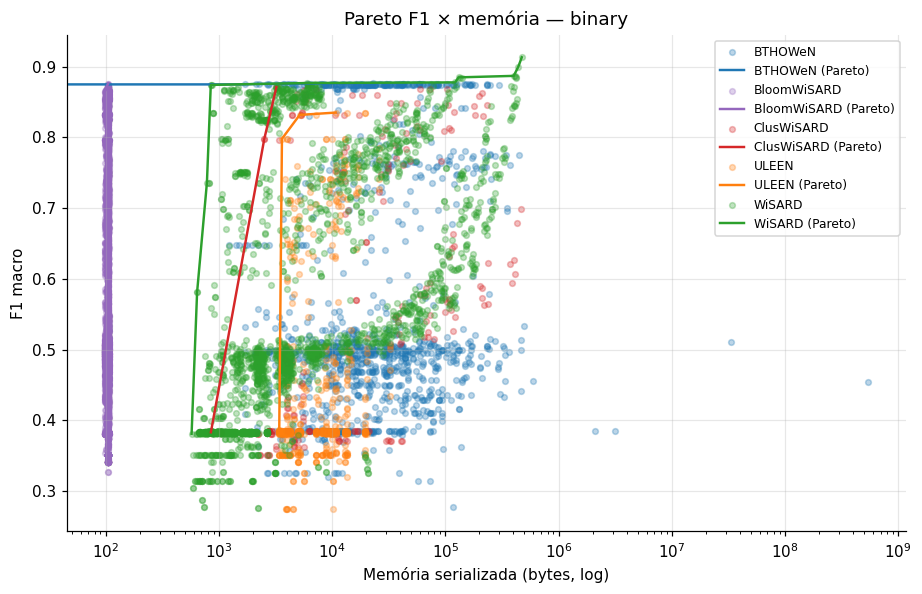

In [9]:
def pareto_front(points):
    pts = np.array(points, float)
    if len(pts) == 0:
        return np.array([], dtype=bool)
    order = np.lexsort((-pts[:,1], pts[:,0]))
    mask = np.zeros(len(pts), dtype=bool)
    best_f1 = -np.inf
    for idx in order:
        if pts[idx,1] > best_f1:
            mask[idx] = True
            best_f1 = pts[idx,1]
    return mask

def plot_pareto_by_model(task, ax):
    sub = df[(df["task"] == task) & (~df["skipped"])
             & df["memory_bytes_serialized"].notna()
             & df["f1_macro"].notna()].copy()
    for model, g in sub.groupby("model"):
        color = COLOR_BY_MODEL.get(model, "gray")
        ax.scatter(g["memory_bytes_serialized"], g["f1_macro"],
                   alpha=0.30, s=14, color=color, label=model)
        pts = list(zip(g["memory_bytes_serialized"], g["f1_macro"]))
        mask = pareto_front(pts)
        front = g.iloc[mask].sort_values("memory_bytes_serialized")
        ax.plot(front["memory_bytes_serialized"], front["f1_macro"],
                color=color, lw=1.6, label=f"{model} (Pareto)")
    ax.set_xscale("log")
    ax.set_xlabel("Memória serializada (bytes, log)")
    ax.set_ylabel("F1 macro")
    ax.set_title(f"Pareto F1 × memória — {task}")
    ax.grid(alpha=0.3)
    ax.legend(fontsize=8)

fig, ax = plt.subplots(figsize=(8.5, 5.5))
plot_pareto_by_model("binary", ax)
plt.tight_layout()
plt.show()

### 4.1 Pareto por base (binário)

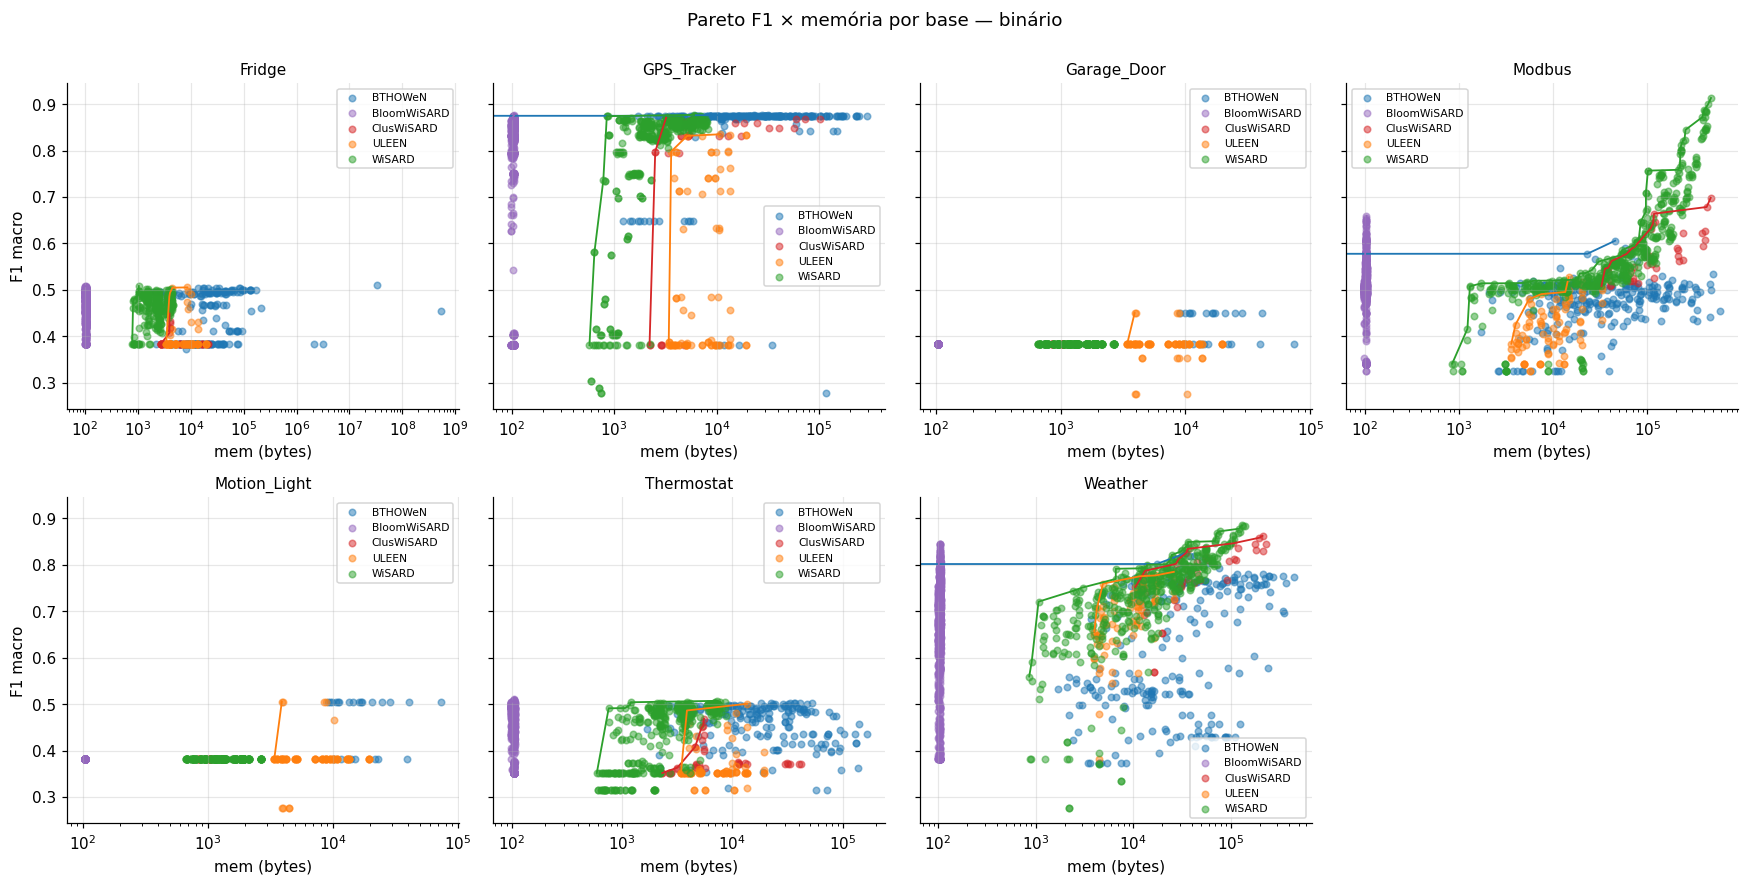

In [10]:
bases = sorted(df["base"].dropna().unique())
fig, axes = plt.subplots(2, 4, figsize=(16, 8), sharey=True)
axes = axes.flatten()
for i, base in enumerate(bases):
    ax = axes[i]
    sub = df[(df["base"] == base) & (df["task"] == "binary") & (~df["skipped"])
             & df["memory_bytes_serialized"].notna()
             & df["f1_macro"].notna()]
    for model, g in sub.groupby("model"):
        color = COLOR_BY_MODEL.get(model, "gray")
        ax.scatter(g["memory_bytes_serialized"], g["f1_macro"],
                   alpha=0.5, s=18, color=color, label=model)
        pts = list(zip(g["memory_bytes_serialized"], g["f1_macro"]))
        mask = pareto_front(pts)
        front = g.iloc[mask].sort_values("memory_bytes_serialized")
        if mask.any():
            ax.plot(front["memory_bytes_serialized"], front["f1_macro"],
                    color=color, lw=1.2)
    ax.set_xscale("log")
    ax.set_title(base, fontsize=10)
    ax.grid(alpha=0.3)
    if i % 4 == 0:
        ax.set_ylabel("F1 macro")
    ax.set_xlabel("mem (bytes)")
    ax.legend(fontsize=7)
for j in range(len(bases), len(axes)):
    axes[j].axis("off")
plt.suptitle("Pareto F1 × memória por base — binário", y=1.0)
plt.tight_layout()
plt.show()

## 5. Matrizes de confusão dos vencedores (binário)

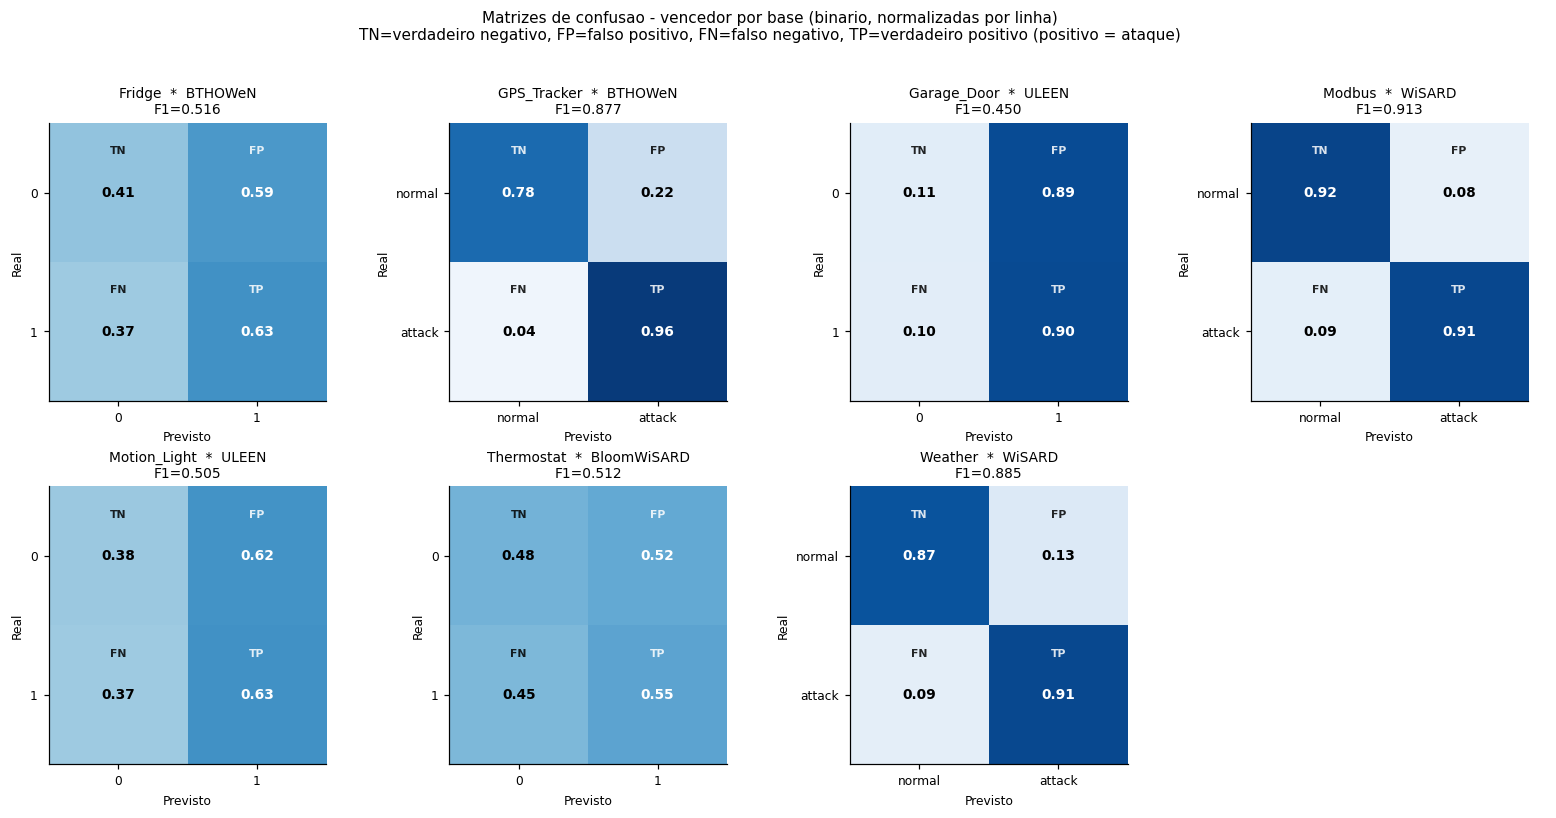

In [11]:
def _orient_binary(cm, labels):
    """Reordena CM 2x2 pra positivo (attack/1) ficar sempre no indice 1.

    Os integrantes salvam labels em ordens diferentes ([0,1], [normal,attack],
    [attack,normal], ...). Padronizamos aqui pra TP/TN/FP/FN ficarem
    consistentes no plot.
    """
    if cm.shape != (2, 2) or not labels or len(labels) != 2:
        return cm, labels
    POS_TOKENS = {"1", "attack", "anomaly", "positive"}
    lower = [str(l).strip().lower() for l in labels]
    if lower[0] in POS_TOKENS and lower[1] not in POS_TOKENS:
        # positivo esta no indice 0 -> swap
        cm = cm[[1, 0]][:, [1, 0]]
        labels = [labels[1], labels[0]]
    return cm, labels


def plot_confusion(ax, cm, labels, title):
    cm = np.array(cm, dtype=float)
    if cm.size == 0:
        ax.text(0.5, 0.5, "N/A", ha="center", va="center")
        ax.set_title(title, fontsize=9)
        ax.axis("off")
        return
    cm, labels = _orient_binary(cm, list(labels))
    cm_norm = cm / cm.sum(axis=1, keepdims=True).clip(min=1)
    ax.imshow(cm_norm, cmap="Blues", vmin=0, vmax=1)
    for (i, j), v in np.ndenumerate(cm_norm):
        color = "white" if v > 0.5 else "black"
        ax.text(j, i, f"{v:.2f}", ha="center", va="center",
                color=color, fontsize=9, fontweight="bold")
    # Binario (2x2): anotar TN/FP/FN/TP nos cantos.
    # Convencao garantida pelo _orient_binary: classe positiva = indice 1.
    if cm.shape == (2, 2):
        quad = {(0, 0): "TN", (0, 1): "FP",
                (1, 0): "FN", (1, 1): "TP"}
        for (i, j), tag in quad.items():
            color = "white" if cm_norm[i, j] > 0.5 else "black"
            ax.text(j, i - 0.30, tag, ha="center", va="center",
                    color=color, fontsize=7, alpha=0.85,
                    fontweight="bold")
    ax.set_xticks(range(len(labels)))
    ax.set_yticks(range(len(labels)))
    ax.set_xticklabels(labels, rotation=0, ha="center", fontsize=8)
    ax.set_yticklabels(labels, fontsize=8)
    ax.set_xlabel("Previsto", fontsize=8)
    ax.set_ylabel("Real", fontsize=8)
    ax.set_title(title, fontsize=9)

n = len(winners_bin)
ncol = 4
nrow = (n + ncol - 1) // ncol
fig, axes = plt.subplots(nrow, ncol, figsize=(3.6*ncol, 3.6*nrow))
axes = axes.flatten() if n > 1 else [axes]
for i, (_, row) in enumerate(winners_bin.iterrows()):
    title = f"{row['base']}  *  {row['model']}\nF1={row['f1_macro']:.3f}"
    plot_confusion(axes[i], row["confusion_matrix"], row["labels"] or [], title)
for j in range(n, len(axes)):
    axes[j].axis("off")
plt.suptitle("Matrizes de confusao - vencedor por base (binario, normalizadas por linha)\n"
             "TN=verdadeiro negativo, FP=falso positivo, FN=falso negativo, TP=verdadeiro positivo "
             "(positivo = ataque)",
             y=1.02, fontsize=10)
plt.tight_layout()
plt.show()


## 6. Anexo: multi-classe

Multi-classe colapsa nas bases com features fracas (Fridge,
Thermostat, Motion_Light, Garage_Door — F1 ≈ 0.07-0.14). Sobrevivem
**Weather** (F1 ≈ 0.83, WiSARD), **Modbus** (F1 ≈ 0.83, WiSARD) e
**GPS_Tracker** (F1 ≈ 0.43, BloomWiSARD; WiSARD logo atrás em 0.42)
— em todos esses, o full grid PLANO §3.1 + `addressSize=32` destravou
o sinal multi-classe também.

O **AUC OvR**, que mede separabilidade *antes* do threshold, sobrevive
em mais casos — os modelos *rankeiam* as classes bem mesmo quando o
argmax erra. Reportamos as duas métricas.

Justificativa pra apresentação focar em binário: nas bases pobres de
feature, ataque/não-ataque é o problema decidível; identificar o tipo
exato requer mais sinal e, mesmo onde há sinal forte (Weather/Modbus),
a tabela binária é mais intuitiva pra audiência.

In [12]:
best_mc = sw.best_per_base(df, "f1_macro")
best_mc = best_mc[best_mc["task"] == "multiclass"].copy()

# Também o melhor por AUC (independente — pode ser config diferente)
best_mc_auc = sw.best_per_base(df, "auc_roc")
best_mc_auc = best_mc_auc[best_mc_auc["task"] == "multiclass"][
    ["model","base","auc_roc","encoder_type","encoder_size","address_size"]
].rename(columns={
    "auc_roc": "best_auc_roc",
    "encoder_type": "auc_thermo", "encoder_size": "auc_thermo_size",
    "address_size": "auc_addr_size",
})

mc_view = best_mc[["model","base","f1_macro","auc_roc",
                   "encoder_type","encoder_size","address_size"]].rename(columns={
    "auc_roc": "auc_at_best_f1"
}).merge(best_mc_auc, on=["model","base"], how="left")
mc_view.sort_values(["base","f1_macro"], ascending=[True, False])

,model,base,f1_macro,auc_at_best_f1,encoder_type,encoder_size,address_size,best_auc_roc,auc_thermo,auc_thermo_size,auc_addr_size
1,BloomWiSARD,Fridge,0.124578,0.494896,Distributive,16,8,0.508667,Gaussian,16,8
4,WiSARD,Fridge,0.123245,0.497357,Simple,64,16,0.507245,Distributive,32,16
3,ULEEN,Fridge,0.121102,NaN,linear,8,16,NaN,NaN,<NA>,<NA>
0,BTHOWeN,Fridge,0.097473,0.501828,Gaussian,4,4,0.501828,Gaussian,4,4
2,ClusWiSARD,Fridge,0.085052,NaN,Gaussian,16,8,NaN,NaN,<NA>,<NA>
6,BloomWiSARD,GPS_Tracker,0.428488,0.762613,Simple,64,32,0.843081,Exponential,64,32
9,WiSARD,GPS_Tracker,0.419531,0.806874,Simple,64,32,0.841789,Gaussian,64,28
7,ClusWiSARD,GPS_Tracker,0.377222,NaN,Distributive,32,16,NaN,NaN,<NA>,<NA>
5,BTHOWeN,GPS_Tracker,0.356698,0.770215,Gaussian,32,8,0.832861,Gaussian,64,28
8,ULEEN,GPS_Tracker,0.338516,NaN,gaussian,16,8,NaN,NaN,<NA>,<NA>


### 6.1 Matrizes de confusão multi-classe (Weather e Modbus)

Casos onde o multi-classe **não colapsa** — os dois usam como
case-study na apresentação.

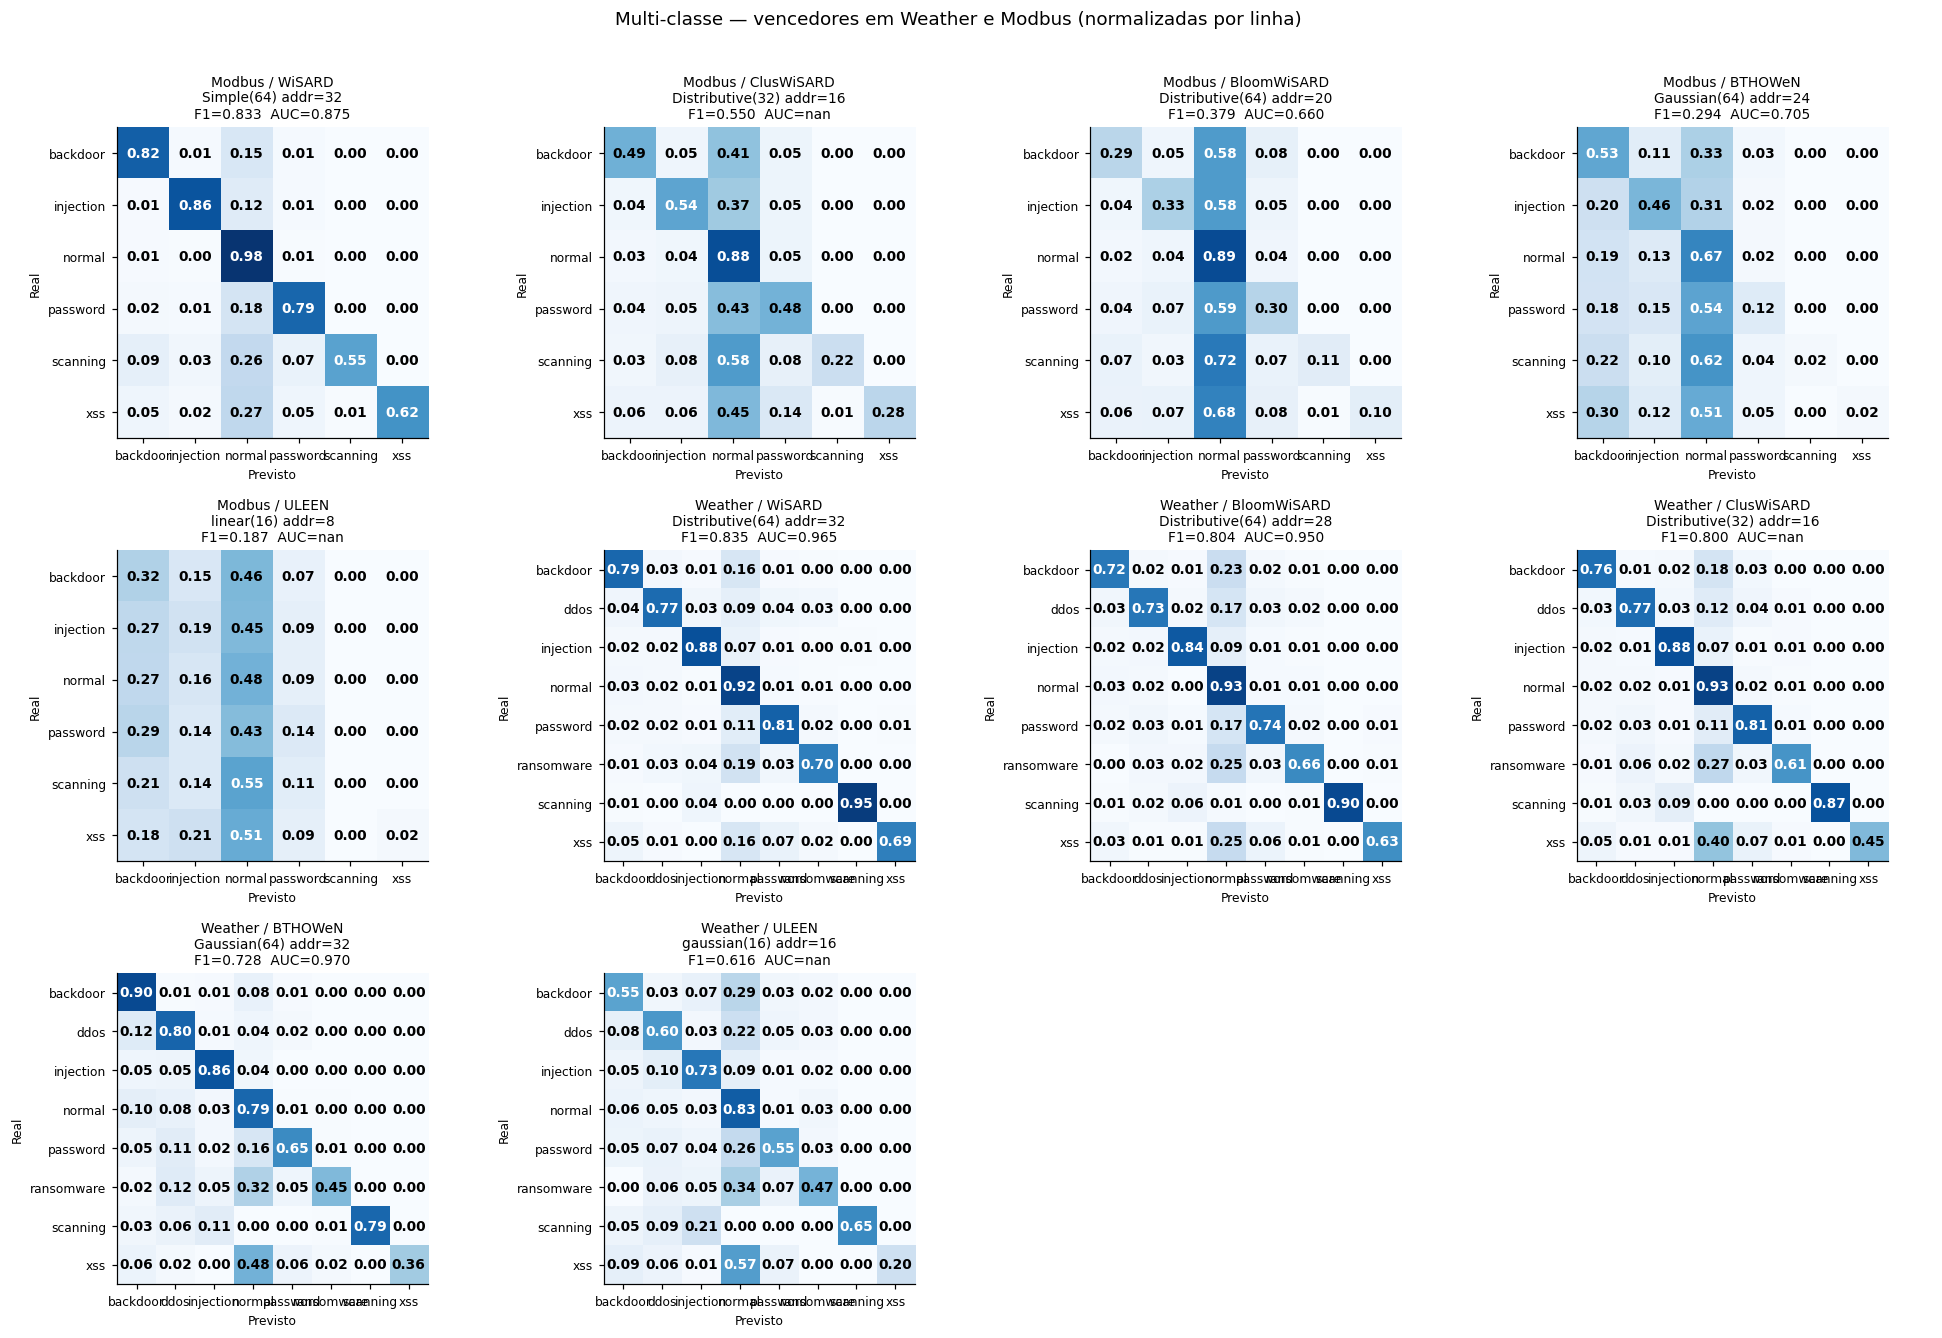

In [13]:
survivors = best_mc[best_mc["base"].isin(["Weather", "Modbus"])].sort_values(
    ["base", "f1_macro"], ascending=[True, False])
n = len(survivors)
ncol = 4
nrow = (n + ncol - 1) // ncol
fig, axes = plt.subplots(nrow, ncol, figsize=(4.5*ncol, 4.0*nrow))
axes = axes.flatten() if n > 1 else [axes]
for i, (_, row) in enumerate(survivors.iterrows()):
    title = (f"{row['base']} / {row['model']}\n"
             f"{row['encoder_type']}({row['encoder_size']}) "
             f"addr={row['address_size']}\n"
             f"F1={row['f1_macro']:.3f}  AUC={row['auc_roc']:.3f}")
    plot_confusion(axes[i], row["confusion_matrix"], row["labels"] or [], title)
for j in range(n, len(axes)):
    axes[j].axis("off")
plt.suptitle("Multi-classe — vencedores em Weather e Modbus (normalizadas por linha)",
             y=1.01)
plt.tight_layout()
plt.show()

## 7. Limites informacionais: lift acima do baseline majoritário

A primeira versão dessa análise tratava Garage_Door e Motion_Light como
"casos patológicos juntos". A análise mais fina (chi-square univariado
+ comparação contra o piso da classe majoritária) mostra que as bases
ficam num **espectro de qualidade de feature**, não numa dicotomia.

### 7.1 Tabela headline: piso × best × lift × Cramér's V

(Dados pós full grid PLANO §3.1 + todas as 5 entregas.)

| Base         | Piso F1 | Best F1 | **Lift**   | Cramér's V máx | Melhor modelo | Categoria |
|--------------|--------:|--------:|-----------:|----------------:|---------------|-----------|
| Modbus       | 0.341   | **0.913** | **+0.572** | 0.040 | WiSARD      | 🟡→🟢 interações multi-feature |
| Weather      | 0.382   | 0.885   | **+0.503** | 0.573 | WiSARD      | 🟢 sinal forte |
| GPS_Tracker  | 0.381   | 0.877   | **+0.496** | 0.769 | BTHOWeN     | 🟢 sinal forte |
| Thermostat   | 0.352   | 0.512   | +0.160     | 0.020 | BloomWiSARD | 🟠 sinal fraco mas presente |
| Fridge       | 0.384   | 0.516   | +0.131     | 0.013 | BTHOWeN     | 🟠 sinal fraco mas presente |
| Motion_Light | 0.383   | 0.505   | +0.122     | 0.005 | BTHOWeN/ULEEN | 🟠 sinal fraco mas presente |
| Garage_Door  | 0.383   | 0.450   | +0.067     | 0.000 | BTHOWeN/ULEEN | 🔴 features ≡ ruído |

**Piso F1** = F1 macro de prever sempre a classe majoritária (`label = 1`).
**Cramér's V** mede a força de associação entre feature e label
(0 = independência estatística, 1 = associação perfeita).

### 7.2 Interpretação por tier

**🟢 GPS_Tracker, Weather** — features ricas (latitude/longitude;
temperatura/pressão/umidade). Cramér's V alto → o sinal está visível
até em chi-square univariada. Modelos atingem F1 ≈ 0.88 e lift de
quase +0.5 sobre o piso.

**🟢 Modbus (promovido com full grid)** — paradoxo aparente: Cramér's
V univariado ≈ 0.04, mas com o full grid (incluindo `addressSize=32`),
WiSARD do integrante atinge F1=**0.913** (lift +0.572). Cada um dos 4
registros Modbus sozinho não discrimina, mas a **combinação de 4
features em n-tupla grande** sim. Esse é exatamente o regime onde
n-tupla é a representação certa — **testemunha forte do valor da
família WNN** pra dados de protocolo de baixo nível. Com
`addressSize ≤ 16` o lift era só +0.347.

**🟠 Thermostat, Fridge, Motion_Light** — features fracas mas com
sinal residual. Lift de +0.12 a +0.16 acima do piso. Causa provável:
features instantâneas (temperatura agora, motion=on agora) carregam
pouca informação sobre se o evento é ataque. Hipóteses testadas e
descartadas: **features temporais não ajudam** nesses 3 datasets;
**addressSize menor também não ajuda** (gargalo é informação no
input, não capacidade do modelo).

**🔴 Garage_Door** — caso patológico real. Cramér's V = 0.000 em
ambas as features → estatisticamente independentes do label.
Nenhum modelo IID pode superar o piso majoritário aqui. Que BTHOWeN
colab chegue a +0.067 acima do piso provavelmente é só uma flutuação
de cobertura de grid.

### 7.3 O que reportar

- Sucesso em GPS_Tracker, Weather, **Modbus** (🟢): F1 ≈ 0.88-0.91
  com modelos da ordem de KB a centenas de KB.
- **Demonstração do valor de n-tupla grande**: o salto Modbus
  +0.347 → +0.572 com `addressSize` de 16 → 32 evidencia que
  capturar interações 4-feature é o que destrava o sinal aqui.
- Limite em Fridge/Thermostat/Motion_Light (🟠): teto a F1 ≈ 0.51
  com features instantâneas; sem ajuda de temporal ou addressSize.
- Limite em Garage_Door (🔴): independência estatística feature × label;
  qualquer modelo IID está fadado ao piso. Lição metodológica:
  reportar o piso da classe majoritária em qualquer trabalho de
  classificação binária desbalanceada — sem ele, F1=0.45 parece
  "ruim mas razoável" quando na verdade é "no chão".

In [14]:
from sklearn.metrics import f1_score as _f1
from scipy.stats import chi2_contingency

# Reusa o loader pra computar o piso/lift; Cramér's V vem dos CSVs originais.
DATA = Path("../../data/toniot")

def majority_floor_f1(y):
    """F1 macro de sempre prever a classe majoritária (binário)."""
    y = np.asarray(y).astype(int)
    return _f1(y, np.ones_like(y), average="macro")

def cramers_v_max(base):
    """Maior Cramér's V entre as features da base (label vs feature)."""
    df = sw.clean_df(pd.read_csv(DATA / f"Train_Test_IoT_{base}.csv"))
    num_cols, cat_cols = sw.FEATURE_COLS[base]
    vals = []
    for col in num_cols + cat_cols:
        if pd.api.types.is_numeric_dtype(df[col]) and df[col].nunique() > 10:
            try:
                series = pd.qcut(df[col].astype(float), 10, duplicates="drop")
            except Exception:
                series = df[col].astype(str)
        else:
            series = df[col].astype(str)
        ct = pd.crosstab(series, df["label"])
        if ct.shape[0] < 2 or ct.shape[1] < 2:
            vals.append(0.0); continue
        chi2, _, _, _ = chi2_contingency(ct)
        n = ct.values.sum()
        vals.append(np.sqrt(chi2 / (n * (min(ct.shape) - 1))))
    return max(vals) if vals else float("nan")

rows = []
for base in sorted(df["base"].dropna().unique()):
    df_raw = sw.clean_df(pd.read_csv(DATA / f"Train_Test_IoT_{base}.csv"))
    _, df_te = sw.make_split(df_raw, "label")
    floor = majority_floor_f1(df_te["label"])
    sub = best_bin[best_bin["base"] == base]
    if not len(sub):
        continue
    best_row = sub.sort_values("f1_macro", ascending=False).iloc[0]
    rows.append({
        "base": base,
        "piso_f1": round(floor, 3),
        "best_f1": round(best_row["f1_macro"], 3),
        "lift": round(best_row["f1_macro"] - floor, 3),
        "cramers_v_max": round(cramers_v_max(base), 3),
        "best_modelo": best_row["model"],
    })

tier_table = (pd.DataFrame(rows)
                .sort_values("lift", ascending=False)
                .reset_index(drop=True))
tier_table

,base,piso_f1,best_f1,lift,cramers_v_max,best_modelo
0,Modbus,0.341,0.913,0.572,0.040,WiSARD
1,Weather,0.382,0.885,0.503,0.573,WiSARD
2,GPS_Tracker,0.381,0.877,0.496,0.769,BTHOWeN
3,Thermostat,0.352,0.512,0.160,0.020,BloomWiSARD
4,Fridge,0.384,0.516,0.131,0.013,BTHOWeN
5,Motion_Light,0.383,0.505,0.122,0.005,BTHOWeN
6,Garage_Door,0.383,0.450,0.067,0.000,BTHOWeN


## 8. Achados consolidados — 5/5 entregas (2026-05-22)

Todas as 5 entregas processadas + gabarito local (`_reference/`) pra
validação cruzada. Total ≈ 32 mil linhas no DataFrame distribuídas em
11 submissões.

### 8.1 Vencedor por base (binário)

| base         | modelo      | submissão             | F1     | mem (B)   | encoder        | addr |
|--------------|-------------|-----------------------|-------:|----------:|----------------|-----:|
| Fridge       | BTHOWeN     | reference             | 0.516  | —¹        | Gaussian(32)   | 16   |
| GPS_Tracker  | BTHOWeN     | colab                 | 0.877  | 23 118    | Gaussian(64)   | 32   |
| Garage_Door  | BTHOWeN/ULEEN | colab/reference     | 0.450  | 9 123/3 919 | Gaussian(4)  | 4    |
| **Modbus**   | **WiSARD**  | **entrega**           | **0.913** | 473 535 | Distributive(64) | 32 |
| Motion_Light | BTHOWeN/ULEEN | colab/reference     | 0.505  | 9 123/3 919 | Gaussian(4)  | 4    |
| Thermostat   | BloomWiSARD | entrega               | 0.512  | **104**   | Distributive(32) | 28 |
| **Weather**  | **WiSARD**  | **entrega**           | **0.885** | 130 875 | Distributive(64) | 32 |

¹ `bthowen_reference` reporta `memory=0` em alguns casos (bug do
`model_size_bytes()` quando bleach colapsa). Reportar via `colab`/`vscode`
pra Pareto.

**Contagem cross-modelo**: BTHOWeN vence/empata 4 bases, WiSARD 2,
BloomWiSARD 1, ULEEN empata em 2 patológicas (Motion_Light/Garage_Door).

**Maior achado**: a entrega WiSARD bate o gabarito em Modbus
(`0.913 > 0.887`) e Weather (`0.885 > 0.883`). Confirma WiSARD
clássico como modelo top do trabalho.

### 8.2 Validação cruzada — entrega × gabarito por modelo

Para cada modelo, comparamos o melhor F1 binário por base na **entrega
do integrante** vs no **gabarito local** rodado pelo coringa
(`_reference/`).

**WiSARD (entrega vs ref)** — match quase perfeito (Δ ≤ ±0.03 em todas
as 7 bases). Implementação WiSARD do integrante validada.

**BTHOWeN (entrega Colab+VsCode vs ref)** — match dentro de ±0.06.
Modbus e Weather: entrega ligeiramente à frente (coberturas
específicas que pegaram bem o ótimo).

**BloomWiSARD (entrega pure-Python vs ref C++)** — concorda em quase
tudo; gap principal em Modbus (-0.091) porque a entrega não varreu
`addressSize=32` (grid menor: até 16). Pure-Python validada como correta.

**ULEEN (entrega expandida em 2026-05-22 vs ref)** — grid agora com 72
cfgs/file (2 thermos × 3 sizes × 3 addrs × 2 epochs, vs 8 antes).
Dispersão caiu (deltas em Fridge e Thermostat encolheram), mas o
gap em Motion_Light persiste:

| base         | entrega | ref   | Δ      |
|--------------|--------:|------:|-------:|
| Fridge       | 0.432   | 0.505 | -0.073 |
| GPS_Tracker  | 0.835   | 0.633 | **+0.202** |
| Garage_Door  | 0.383   | 0.450 | -0.067 |
| Modbus       | 0.528   | 0.503 | +0.025 |
| Motion_Light | 0.383   | 0.505 | -0.122 |
| Thermostat   | 0.486   | 0.501 | -0.015 |
| Weather      | 0.785   | 0.744 | +0.041 |

ULEEN é estocástico (treino SGD) + grids diferentes em épocas — reportar
ambos lado a lado segue sendo recomendado.

**ClusWiSARD (entrega pure-Python re-run vs ref C++)** — match razoável,
gap esperado pelo pure-Python ser menos otimizado (memory_bytes e
train_time não comparáveis).

### 8.3 Mensagens centrais pra apresentação

- WNN entrega **F1 ≈ 0.88-0.91 em Weather/GPS_Tracker/Modbus** com
  memória variando de **104 B (BloomWiSARD/Thermostat)** a **474 KB
  (WiSARD/Modbus)** — escolha vai por orçamento.
- **WiSARD clássico é o vencedor**: F1 = 0.913 em Modbus e 0.885 em
  Weather — bate ClusWiSARD, BloomWiSARD, BTHOWeN e ULEEN no binário.
  **Não precisa de variantes sofisticadas pra ter desempenho top.**
- **n-tupla grande importa**: Modbus salta lift +0.347 → +0.572 com
  `addressSize` 16 → 32 (mantendo o resto). Captura interações entre
  os 4 registros do protocolo Modbus, invisíveis a Cramér's V
  univariado.
- **BloomWiSARD é o vencedor em Pareto**: F1 ≈ 0.85 em Weather e
  GPS_Tracker com **105 bytes** — 4-5 ordens de magnitude abaixo dos
  competidores. Caso pra deploy embarcado.
- **Multi-classe sobrevive em 3 bases**: Weather, Modbus (ambas F1 ≈
  0.83 com WiSARD) e GPS_Tracker (F1 ≈ 0.43, BloomWiSARD). Nas
  outras 4 bases o multi-classe colapsa.
- Bases pobres (Garage_Door 🔴, e os 🟠) saturam todos os modelos em
  F1 ≈ 0.45-0.51 — **limite informacional** dos features (§7).

### 8.4 Pendências antes do entregável final

- [x] Todas as 5 entregas recebidas e integradas.
- [x] ULEEN entrega expandida (8 → 72 cfgs/file) integrada em 2026-05-22.
- [x] Full grid PLANO §3.1 nos 4 modelos baratos do gabarito.
- [ ] **Bug do BTHOWeN memory=0**: documentar como caveat no relatório;
      usar `colab`/`vscode` na Pareto de BTHOWeN.
- [ ] Slides da apresentação: ver `handoff_apresentacao_2026-05-22.md`.
